# APPLICATION  D'UNE MCMC pour la SIMULATION A POSTERIORI

Donnees X (debit de riviere) ~ Loi de GUMBEL (mu,lambda)  
A priori sur (mu,lambda) = melange de lois Gamma d'hyperparametres (m, alpha, xe.alpha)  
avec :  
m = taille d'echantillon fictif (force de l'expertise)  
xe_alpha = quantile predictif (sur X, donc positif) a priori de seuil alpha (donne par l'expert)  
alpha    = seuil de xe.alpha, compris dans [0,1]  (donne par l'expert)  
lambda_e = moyenne a priori de lambda (donnee par l'expert)

In [74]:
%matplotlib inline
from math import floor
from numpy import log, pi, exp, sqrt
from scipy import __version__ as sci_version
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.special import loggamma
from numpy.random import normal, uniform, gamma
from statistics import mean
from statsmodels.nonparametric.kde import KDEUnivariate
from statsmodels import __version__ as stm_version
from matplotlib import __version__ as mpl_version
from pandas import __version__ as pd_version
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [75]:
print(
      "scipy version " +  sci_version + 
      "\nnumpy version " + np.__version__ +
      "\nmatplotlib version " + mpl_version +
      "\nstatsmodels version " + stm_version +
      "\npandas version " + pd_version
     )

scipy version 1.13.1
numpy version 1.26.4
matplotlib version 3.4.3
statsmodels version 0.14.4
pandas version 2.2.3


## Jeu de donnees 

30 mesures de débit

In [76]:
data = [ 1306, 1235, 1830, 2442, 1128, 3330, 1530, 3192, 2647, 238,  
        706, 1903, 1594,  935, 1100, 2204, 1366, 1629,  522,  642, 1173, 
        424, 1837, 1391, 789,  383, 1858, 917, 1084, 1026]

In [77]:
m = 1
xe_alpha=2000
alpha=0.5
lambda_e=1/2000

##  Algorithme de Metropolis-Hastings-within-Gibbs 

### Densité a priori sur la moyenne

A priori :  
$\lambda \sim Gamma(m, m/\lambda_e)$ en paramètrisation $Gamma(shape, rate)$, $rate = 1/scale $  
$mu \sim Gamma(m, b_m(\lambda))$  en paramètrisation $Gamma(shape, rate)$  
avec $b_m(\lambda) = exp(- \lambda x_{e,\alpha}) / (\alpha^{-1/m} - 1)$

In [78]:
def get_mean_rate_param(l, m, xe_alpha, alpha) :
    """
        Fonction donnant l'hyperparametre d'echelle de la loi a priori de mu
        sachant lambda, m, xe_alpha et alpha
    """
    return exp(- l * xe_alpha) / (alpha ** (- 1 / m) - 1)

def sample_from_prior(n, m, xe_alpha, alpha, lambda_e) :
    """
         Simulation de (mu,lambda) a priori
    """
    l = gamma(shape = m, scale = lambda_e / m, size = n)
    scale_prior = get_mean_rate_param(l, m, xe_alpha, alpha)
    mu = gamma(shape = m, scale = 1 / scale_prior, size = n)
    return {"lambda" : l, "mu" : mu}

### Log-densité a priori sur lambda

In [79]:
def lambda_prior_density(l, lambda_e, m) :
    return m * (log(m) - log(lambda_e)) - loggamma(m) + (m - 1) * log(l) - m * l / lambda_e

### Log-densite a posteriori de lambda 

A posteriori :  
$\pi(\lambda | x_n) = \gamma(\lambda) Gamma(m + n , m/\lambda_e + n\bar{x}_n)$  
avec 
$\bar{x}_n = \frac{1}{n} \sum_{i=1}^n x_i$,  
$\gamma(\lambda) \propto \frac{b^m_m(\lambda)}{(b_m(\lambda) + \bar{b}_{x_n}(\lambda))^{m + n}}$  
et $\bar{b}_{x_n} = \sum_{i = 1}^n exp(-\lambda x_i)$

In [80]:
def compute_informed_parameters(l, uncensored_data = np.array([]), censored_data = np.array([])) :  
    all_data = np.concatenate([uncensored_data, censored_data])
    n = all_data.size
    xn_bar = np.mean(all_data) if n > 0 else 0
    l_arr = np.atleast_1d(l)
    if n > 0 :
        stacked = l_arr.reshape(-1, 1) * all_data.reshape(1, -1)
        b_values = np.sum(exp(- stacked), axis=1)
    else :
        b_values = np.zeros(l_arr.shape)
    b_xn = b_values.item() if l_arr.ndim == 0 else b_values
    return n, xn_bar, b_xn


def lambda_log_posterior(l, m, xe_alpha, alpha, lambda_e, uncensored_data, censored_data) :
    n, xn_bar, b_xn = compute_informed_parameters(l, uncensored_data, censored_data)
    bm = get_mean_rate_param(l, m, xe_alpha, alpha)
    log_gamma = m * log(bm) - (m + n) * log(bm + b_xn)
    log_prior_lambda = lambda_prior_density(l, lambda_e, m)
    return log_gamma + log_prior_lambda

### Simulation conditionnelle de Gibbs de mu sachant lambda a posteriori

In [81]:
def sample_mu_from_posterior(l, m, xe_alpha, alpha, lambda_e,
                           uncensored_data, censored_data) :
    n, xn_bar, b_xn = compute_informed_parameters(l, uncensored_data, censored_data)
    bm = get_mean_rate_param(l, m, xe_alpha, alpha)
    shape_post = m + n
    scale_post = 1 / (bm + b_xn)
    return gamma(shape = shape_post, scale = scale_post)

### Estimateurs du maximum de vraisemblance de la loi de Gumbel

 Estimation rapide des estiamteurs du max de vraisemblance de Gumbel sur des donnees non censurees (via un algorithme de simplexe), utilisés pour initialiser les valeurs de mu et lambda.

In [82]:
def log_density_Gumbel(data, mu, l) :
    return log(l) + log(mu) - l * data - mu * exp(- l* data)

def log_likelihood_Gumbel(uncensored_data, censored_data, mu, l) :
    
    ll = 0
    
    if uncensored_data.size > 0 :   
        ll += np.sum(log_density_Gumbel(uncensored_data, mu, l))

    if censored_data.size > 0 :   
        ll += np.sum(- mu * exp(- l* censored_data))

    return ll


def MLE_Gumbel(data, plotting= True) :
    
    # log-vraisemblance negative a minimiser
    data = np.array(data)
    
    def neg_log_likelihood(params) :
        mu, l = params
        if mu <= 0 or l <= 0 :
            return 1e10
        return -log_likelihood_Gumbel(data, np.array([]), mu, l)
    
    x0 = [1.0, 1.0 / np.mean(data)]
    result = minimize(neg_log_likelihood, x0, method = 'Nelder-Mead')
    
    MLE_param = {"mu" : result.x[0], "lambda" : result.x[1]}
    
    if plotting :
        print("MLE mu = ", MLE_param["mu"], ", MLE lambda = ", MLE_param["lambda"])
        
    return MLE_param

### Initialisation de lambda

In [83]:
def initialize_lambda(n_chains, data) :
    MLE = MLE_Gumbel(data, plotting = False)
    return uniform(low = 0, high = 1.5 * MLE["lambda"], size = n_chains)

### Selection de la distribution instrumentale

In [84]:
def make_instrumental_distribution(nb_chains, option, m, xe_alpha, alpha, lambda_e, data) :
    """
        Fonction générant les fonction des log_densite et d'echantillonnage selon l'option selectionnee.
    """
    if option == 1 : 
        
        print("Loi instrumentale choisie : loi a priori\n")
        
        def log_density(x,y) :
            return m * (log(m) - log(lambda_e)) - loggamma(m) + (m - 1) * log(x) - m * x / lambda_e
        
        def sampling(n,x) :
            sample = gamma(shape = m, scale = lambda_e / m, size = (n * nb_chains))
            return np.ndarray(shape =(n,nb_chains), buffer = sample)
    
    
    if option == 2 : 
        
        print("Loi instrumentale choisie : loi gamma semblant proche de l'a posteriori sur lambda\n")
        n = len(data)
        xn = np.mean(data)
        
        def log_density(x,y) :
            return (m + n) * log(m / lambda_e + n * xn) - loggamma(m + n) + (m + n - 1) * log(x) - x * (m / lambda_e + n * xn)
        
        def sampling(n,x) :
            sample = gamma(shape = n + m, scale = 1 / (m / lambda_e + n * xn), size = n * nb_chains)
            return np.ndarray(shape =(n,nb_chains), buffer = sample)

        
    if option == 3 :
        
        print("Loi instrumentale choisie : loi normale de moyenne la valeur courante et de coeff. de variation = 5 %")
        coeff_variation = 0.05
        
        def log_density(x, y) :
            sigma = abs(coeff_variation * y)
            return -0.5 * log(2 * pi) - log(sigma) - (x-y) ** 2 / (2 * (sigma ** 2))
        
        def sampling(n, x) :
            sigma = abs(coeff_variation * x)
            sample = abs(normal(loc = x, scale = sigma, size = n * nb_chains))
            return np.ndarray(shape =(n,nb_chains), buffer = sample)
    
    
    if option == 4 :
        
        print("Loi instrumentale choisie : loi normale de moyenne la valeur courante et de coeff. de variation = 25 %")
        coeff_variation = 0.25
        
        def log_density(x, y) :
            sigma = abs(coeff_variation * y)
            return -0.5 * log(2 * pi) - log(sigma) - (x-y) ** 2 / (2 * (sigma ** 2))
        
        def sampling(n, x) :
            sigma = abs(coeff_variation * x)
            sample = abs(normal(loc = x, scale = sigma, size = n * nb_chains))
            return np.ndarray(shape =(n,nb_chains), buffer = sample)
        
    if option == 5 :
        
        print("Loi instrumentale choisie : loi normale de moyenne la valeur courante et de coeff. de variation = 50 %")
        coeff_variation = 0.5
        
        def log_density(x, y) :
            sigma = abs(coeff_variation * y)
            return -0.5 * log(2 * pi) - log(sigma) - (x-y) ** 2 / (2 * (sigma ** 2))
        
        def sampling(n, x) :
            sigma = abs(coeff_variation * x)
            sample = abs(normal(loc = x, scale = sigma, size = n * nb_chains))
            return np.ndarray(shape =(n,nb_chains), buffer = sample)
        
    return log_density, sampling

### Construction de la fonction de densité a posteriori pour lambda

In [85]:
def make_log_posterior_density(m, xe_alpha, alpha, lambda_e, uncensored_data, censored_data) :
    
    def log_posterior_density(l) :
        return lambda_log_posterior(l, m, xe_alpha, alpha, lambda_e, uncensored_data, censored_data)
    return log_posterior_density

### Diagnostic de l'échantillonnage

####                 Statistique de Brooks-Gelman

calculee sur un nombre nb_chains de chaines MCMC paralleles pour le parametre theta (matrix Nsim x nb_chains)

In [86]:
def Brooks_Gelman(theta, pro = 0.9) :
    n, m = theta.shape
    # Intervalle de credibilite intra-chaine
    q_low = (1 - pro) / 2
    q_high = 1 - q_low
    W = np.mean([np.quantile(theta[:, j], q_high) - np.quantile(theta[:, j], q_low) for j in range(m)])
    # Intervalle de credibilite global (toutes chaines confondues)
    all_samples = theta.flatten()
    B = np.quantile(all_samples, q_high) - np.quantile(all_samples, q_low)
    if W == 0 :
        return np.inf
    return B / W

### Echantillonnage

In [87]:
def metropolis_hastings_sampling(lambda_old, sampling, log_density, log_posterior_density) :
    
    # Proposition
    lambda_new = sampling(1, lambda_old).flatten()
    
    # Log du ratio d'acceptation
    log_alpha = (log_posterior_density(lambda_new) - log_posterior_density(lambda_old)
                 + log_density(lambda_old, lambda_new) - log_density(lambda_new, lambda_old))
    
    # Acceptation / rejet
    log_u = log(uniform(size = len(lambda_old)))
    accept = log_u < log_alpha
    sample = np.where(accept, lambda_new, lambda_old)
    
    return sample

### Graphes

In [88]:
def plot_mcmc(lambda_samples, mu_samples, BG_lambda, BG_mu, burn_in, iteration) :
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    nb_chains = lambda_samples.shape[1]
    
    # Traces de lambda
    for j in range(nb_chains) :
        axes[0, 0].plot(lambda_samples[:, j], alpha=0.7)
    axes[0, 0].set_title("Trace lambda")
    axes[0, 0].axvline(x=burn_in, color='r', linestyle='--')
    
    # Traces de mu
    for j in range(nb_chains) :
        axes[1, 0].plot(mu_samples[:, j], alpha=0.7)
    axes[1, 0].set_title("Trace mu")
    axes[1, 0].axvline(x=burn_in, color='r', linestyle='--')
    
    # Histogramme lambda (apres burn-in)
    for j in range(nb_chains) :
        axes[0, 1].hist(lambda_samples[burn_in:, j], bins=50, alpha=0.5, density=True)
    axes[0, 1].set_title("Histogramme lambda")
    
    # Histogramme mu (apres burn-in)
    for j in range(nb_chains) :
        axes[1, 1].hist(mu_samples[burn_in:, j], bins=50, alpha=0.5, density=True)
    axes[1, 1].set_title("Histogramme mu")
    
    # Brooks-Gelman lambda
    axes[0, 2].plot(BG_lambda)
    axes[0, 2].axhline(y=1, color='r', linestyle='--')
    axes[0, 2].set_title("Brooks-Gelman lambda")
    
    # Brooks-Gelman mu
    axes[1, 2].plot(BG_mu)
    axes[1, 2].axhline(y=1, color='r', linestyle='--')
    axes[1, 2].set_title("Brooks-Gelman mu")
    
    plt.tight_layout()
    plt.show()

### Boucle MCMC complète

In [89]:
def metropolis_hastings_within_gibbs(data, option = 1, N = 1000, burn_in = 5000, nb_chains = 3,
                                     m = 1, xe_alpha = 2000, alpha = 0.5, lambda_e = 1/2000, 
                                     pause = range(1,101), plotting= range(1, 10)) :
    
    uncensored_data = np.array(data)
    censored_data = np.array([])
    
    total = burn_in + N
    
    # Initialisation
    lambda_current = initialize_lambda(nb_chains, data)
    
    lambda_samples = np.zeros((total, nb_chains))
    mu_samples = np.zeros((total, nb_chains))
    
    # Loi instrumentale
    log_density, sampling = make_instrumental_distribution(nb_chains, option, m, xe_alpha, alpha, lambda_e, data)
    
    # Log-posteriori
    log_posterior_density = make_log_posterior_density(m, xe_alpha, alpha, lambda_e, uncensored_data, censored_data)
    
    BG_lambda = []
    BG_mu = []
    
    for i in range(total) :
        # MH step pour lambda
        lambda_current = metropolis_hastings_sampling(lambda_current, sampling, log_density, log_posterior_density)
        lambda_samples[i, :] = lambda_current
        
        # Gibbs step pour mu | lambda
        for j in range(nb_chains) :
            mu_samples[i, j] = sample_mu_from_posterior(lambda_current[j], m, xe_alpha, alpha, lambda_e,
                                                         uncensored_data, censored_data)
        
        # Diagnostic Brooks-Gelman
        if (i + 1) in pause and i > 1 :
            BG_lambda.append(Brooks_Gelman(lambda_samples[:i+1, :]))
            BG_mu.append(Brooks_Gelman(mu_samples[:i+1, :]))
        
        if (i + 1) in plotting :
            print(f"Iteration {i+1}/{total}, BG lambda = {BG_lambda[-1] if BG_lambda else 'N/A'}")
    
    plot_mcmc(lambda_samples, mu_samples, BG_lambda, BG_mu, burn_in, total)
    
    return {"lambda" : lambda_samples[burn_in:, :], "mu" : mu_samples[burn_in:, :]}

Loi instrumentale choisie : loi normale de moyenne la valeur courante et de coeff. de variation = 25 %
Iteration 1/6000, BG lambda = N/A
Iteration 2/6000, BG lambda = N/A
Iteration 3/6000, BG lambda = 3.4106068333243624
Iteration 4/6000, BG lambda = 1.8988898040998554
Iteration 5/6000, BG lambda = 1.7153010465608296
Iteration 6/6000, BG lambda = 1.4636726466365464
Iteration 7/6000, BG lambda = 1.6048804193034505
Iteration 8/6000, BG lambda = 1.538533083373637
Iteration 9/6000, BG lambda = 1.2903726790558263
Iteration 10/6000, BG lambda = 1.130083559327244
Iteration 11/6000, BG lambda = 1.2055225659660986
Iteration 12/6000, BG lambda = 1.150457995743694
Iteration 13/6000, BG lambda = 0.9913826021228743
Iteration 14/6000, BG lambda = 1.1886686934453652
Iteration 15/6000, BG lambda = 1.1260772414437783
Iteration 16/6000, BG lambda = 1.052725211153381
Iteration 17/6000, BG lambda = 1.1860544281432375
Iteration 18/6000, BG lambda = 1.2419076094108803
Iteration 19/6000, BG lambda = 1.2327121

/var/folders/0f/6c8rjvls46g5vw3zh6l1137w0000gn/T/ipykernel_31846/4014420049.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mu_samples[i, j] = sample_mu_from_posterior(lambda_current[j], m, xe_alpha, alpha, lambda_e,
/var/folders/0f/6c8rjvls46g5vw3zh6l1137w0000gn/T/ipykernel_31846/3258511640.py:18: RuntimeWarning: divide by zero encountered in log
  log_gamma = m * log(bm) - (m + n) * log(bm + b_xn)


Iteration 320/6000, BG lambda = 1.0248202795483898
Iteration 321/6000, BG lambda = 1.0248202795483898
Iteration 322/6000, BG lambda = 1.0248202795483898
Iteration 323/6000, BG lambda = 1.0248202795483898
Iteration 324/6000, BG lambda = 1.0248202795483898
Iteration 325/6000, BG lambda = 1.0248202795483898
Iteration 326/6000, BG lambda = 1.0248202795483898
Iteration 327/6000, BG lambda = 1.0248202795483898
Iteration 328/6000, BG lambda = 1.0248202795483898
Iteration 329/6000, BG lambda = 1.0248202795483898
Iteration 330/6000, BG lambda = 1.0248202795483898
Iteration 331/6000, BG lambda = 1.0248202795483898
Iteration 332/6000, BG lambda = 1.0248202795483898
Iteration 333/6000, BG lambda = 1.0248202795483898
Iteration 334/6000, BG lambda = 1.0248202795483898
Iteration 335/6000, BG lambda = 1.0248202795483898
Iteration 336/6000, BG lambda = 1.0248202795483898
Iteration 337/6000, BG lambda = 1.0248202795483898
Iteration 338/6000, BG lambda = 1.0248202795483898
Iteration 339/6000, BG lambda =

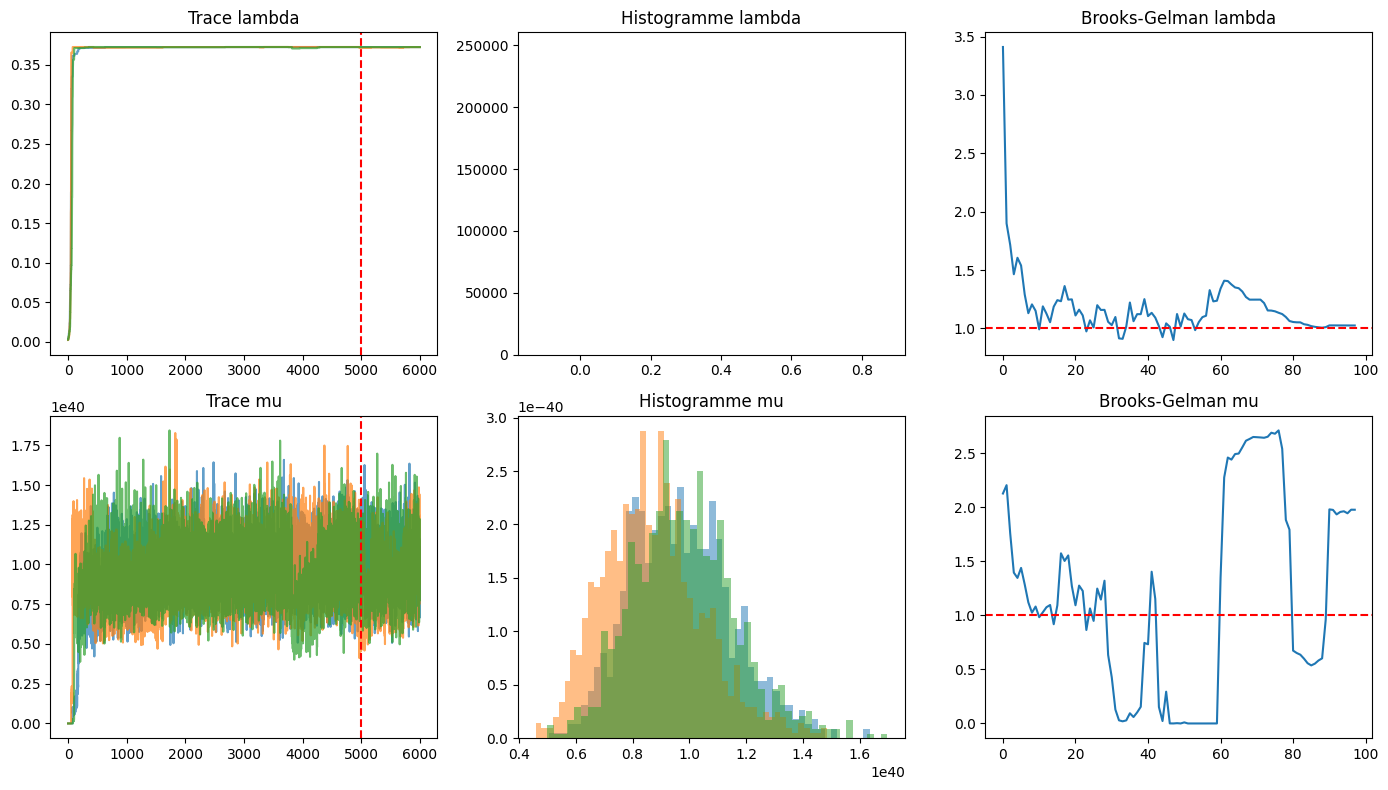

{'lambda': array([[0.37239417, 0.3714161 , 0.37247369],
        [0.37239417, 0.3714161 , 0.37247369],
        [0.37239417, 0.3714161 , 0.37247369],
        ...,
        [0.3724044 , 0.37241831, 0.37247369],
        [0.3724044 , 0.37241831, 0.37247369],
        [0.3724044 , 0.37241831, 0.37247369]]),
 'mu': array([[1.06436937e+40, 6.83791325e+39, 9.29210684e+39],
        [6.75036240e+39, 8.16419691e+39, 7.93094534e+39],
        [8.36052845e+39, 7.68502609e+39, 8.04846392e+39],
        ...,
        [1.05777328e+40, 1.17361740e+40, 9.82814492e+39],
        [6.91728305e+39, 8.82287123e+39, 1.10467977e+40],
        [6.68031831e+39, 1.00734805e+40, 1.04145273e+40]])}

In [96]:
# test 
results = metropolis_hastings_within_gibbs(data, option = 4, N = 1000, burn_in = 5000, nb_chains = 3,
                                     m = 1, xe_alpha = 2000, alpha = 0.5, lambda_e = 1/2000, 
                                     pause = range(1,101), plotting= range(1, 1000))

results